In [67]:
import pandas as pd
import numpy as np
import scipy as stats
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)


In [68]:
df=pd.read_csv(r"C:\Users\niles\Downloads\Order_Table.csv")

In [69]:
df

,Unnamed: 0,Customer_ID,Age,Monthly_Income,Order_Value,Orders_Per_Month,Discount_Percentage,Delivery_Time_Days
0,0,1102,33,42505.468953,2713.289625,5,6.526358,1.398059
1,1,1435,42,49081.559372,3911.843373,1,1.778820,3.272074
2,2,1860,32,64929.355993,1813.401346,5,9.257799,3.507662
3,3,1270,41,41326.697501,3279.828214,2,13.610320,6.636292
4,4,1106,19,66699.084691,4776.384497,3,5.193985,7.334388
...,...,...,...,...,...,...,...,...
4995,4995,1289,26,24051.414539,3071.836870,3,14.263375,9.806655
4996,4996,1294,23,53217.928542,3210.935476,0,9.494472,1.181611
4997,4997,1450,20,43383.122012,3416.314100,6,8.815458,6.021934
4998,4998,1903,39,27439.535148,2987.315893,4,1.620958,9.091445


In [70]:
mean=df[['Order_Value', 'Monthly_Income', 'Delivery_Time_Days']].mean()

In [71]:
mean

Order_Value            3012.348958
Monthly_Income        49931.221872
Delivery_Time_Days        5.027623
dtype: float64

In [72]:
median=df[['Order_Value', 'Monthly_Income', 'Delivery_Time_Days']].median()

In [73]:
median

Order_Value            3030.114260
Monthly_Income        49782.401032
Delivery_Time_Days        5.025744
dtype: float64

In [74]:
mode=df[['Order_Value', 'Monthly_Income', 'Delivery_Time_Days']].mode().iloc[0]

In [75]:
mode

Order_Value           -251.682515
Monthly_Income       -6361.529819
Delivery_Time_Days      -3.590782
Name: 0, dtype: float64

In [76]:
skew=df[['Order_Value', 'Monthly_Income', 'Delivery_Time_Days']].skew()

In [77]:
skew

Order_Value          -0.074816
Monthly_Income        0.003115
Delivery_Time_Days   -0.040328
dtype: float64

# skew is negative 

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

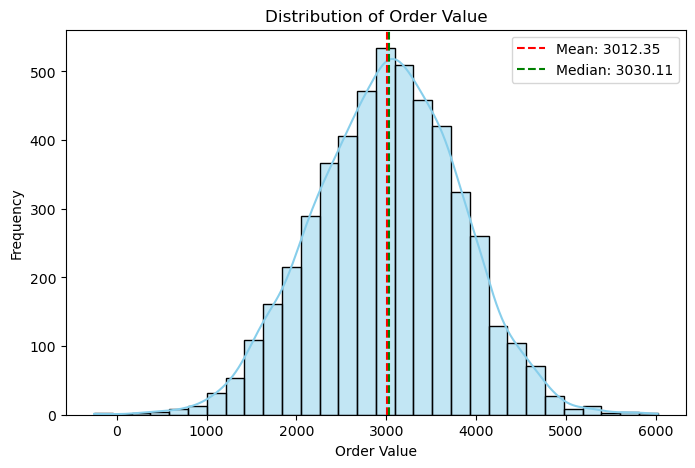

In [79]:
plt.figure(figsize=(8,5))
sns.histplot(df['Order_Value'], bins=30, kde=True, color='skyblue')

# Add mean and median linesexplain

plt.axvline(df['Order_Value'].mean(), color='red', linestyle='--', label=f"Mean: {df['Order_Value'].mean():.2f}")
plt.axvline(df['Order_Value'].median(), color='green', linestyle='--', label=f"Median: {df['Order_Value'].median():.2f}")

plt.title("Distribution of Order Value")
plt.xlabel("Order Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()


# measure of dispersion

# variance

In [80]:
var=df[['Order_Value', 'Monthly_Income', 'Delivery_Time_Days']].var()

In [81]:
var

Order_Value           6.457630e+05
Monthly_Income        2.308751e+08
Delivery_Time_Days    3.965947e+00
dtype: float64

# std

In [82]:
std=df[['Order_Value', 'Monthly_Income', 'Delivery_Time_Days']].std()

In [83]:
std

Order_Value             803.593785
Monthly_Income        15194.573157
Delivery_Time_Days        1.991469
dtype: float64

mean=3012.348958 and std=803.593785 mean is noth the means the we are not predict the revenue and we are not says that the customers are consist

# interquartile range

In [84]:
# Order Value IQR
Q1_order = df['Order_Value'].quantile(0.25)
Q3_order = df['Order_Value'].quantile(0.75)
IQR_order = Q3_order - Q1_order

# Monthly Income IQR
Q1_income = df['Monthly_Income'].quantile(0.25)
Q3_income = df['Monthly_Income'].quantile(0.75)
IQR_income = Q3_income - Q1_income

# Delivery Time Days IQR
Q1_delivery = df['Delivery_Time_Days'].quantile(0.25)
Q3_delivery = df['Delivery_Time_Days'].quantile(0.75)
IQR_delivery = Q3_delivery - Q1_delivery

print("Order Value IQR:", IQR_order)
print("Monthly Income IQR:", IQR_income)
print("Delivery Time Days IQR:", IQR_delivery)

Order Value IQR: 1100.5304973266775
Monthly Income IQR: 20589.899579828518
Delivery Time Days IQR: 2.704167226388776


# mean absolute deviation

In [85]:
mad_order = np.mean(np.abs(df['Order_Value'] - df['Order_Value'].mean()))
mad_income = np.mean(np.abs(df['Monthly_Income'] - df['Monthly_Income'].mean()))
mad_delivery = np.mean(np.abs(df['Delivery_Time_Days'] - df['Delivery_Time_Days'].mean()))

print("Order Value MAD:", mad_order)
print("Monthly Income MAD:", mad_income)
print("Delivery Time Days MAD:", mad_delivery)


Order Value MAD: 640.9295296770188
Monthly Income MAD: 12095.904278815784
Delivery Time Days MAD: 1.5888156670324416


# 25% and 50% 75%

In [86]:
percentiles = [0.25, 0.50, 0.75]

order_value_percentiles = df['Order_Value'].quantile(percentiles)
monthly_income_percentiles = df['Monthly_Income'].quantile(percentiles)
delivery_time_percentiles = df['Delivery_Time_Days'].quantile(percentiles)

print("Order Value Percentiles:\n", order_value_percentiles)
print("\nMonthly Income Percentiles:\n", monthly_income_percentiles)
print("\nDelivery Time Days Percentiles:\n", delivery_time_percentiles)

Order Value Percentiles:
 0.25    2464.467677
0.50    3030.114260
0.75    3564.998174
Name: Order_Value, dtype: float64

Monthly Income Percentiles:
 0.25    39652.242799
0.50    49782.401032
0.75    60242.142379
Name: Monthly_Income, dtype: float64

Delivery Time Days Percentiles:
 0.25    3.690550
0.50    5.025744
0.75    6.394717
Name: Delivery_Time_Days, dtype: float64


In [87]:
cv=std/mean

In [88]:
cv

Order_Value           0.266766
Monthly_Income        0.304310
Delivery_Time_Days    0.396105
dtype: float64

<Axes: >

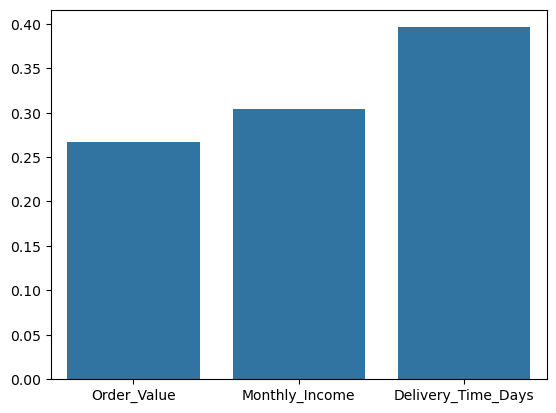

In [89]:
sns.barplot(cv)

# age columns

In [90]:
df['Age'].isnull().sum()

np.int64(0)

In [91]:
df['Age']

0       33
1       42
2       32
3       41
4       19
        ..
4995    26
4996    23
4997    20
4998    39
4999    21
Name: Age, Length: 5000, dtype: int64

In [92]:
df

,Unnamed: 0,Customer_ID,Age,Monthly_Income,Order_Value,Orders_Per_Month,Discount_Percentage,Delivery_Time_Days
0,0,1102,33,42505.468953,2713.289625,5,6.526358,1.398059
1,1,1435,42,49081.559372,3911.843373,1,1.778820,3.272074
2,2,1860,32,64929.355993,1813.401346,5,9.257799,3.507662
3,3,1270,41,41326.697501,3279.828214,2,13.610320,6.636292
4,4,1106,19,66699.084691,4776.384497,3,5.193985,7.334388
...,...,...,...,...,...,...,...,...
4995,4995,1289,26,24051.414539,3071.836870,3,14.263375,9.806655
4996,4996,1294,23,53217.928542,3210.935476,0,9.494472,1.181611
4997,4997,1450,20,43383.122012,3416.314100,6,8.815458,6.021934
4998,4998,1903,39,27439.535148,2987.315893,4,1.620958,9.091445


In [93]:
df['Age'].min()

0

In [94]:
df['Age'].max()

67

In [95]:
bins = [18, 25, 35, 45, 55, 67]
labels = ['18-25', '26-35', '36-45', '46-55', '56-67']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Calculate IQR for Order_Value
variability = df.groupby('Age_Group')['Order_Value'].agg(
    Q1=lambda x: x.quantile(0.25),
    Q3=lambda x: x.quantile(0.75)
)

variability['IQR'] = variability['Q3'] - variability['Q1']

print(variability.sort_values('IQR', ascending=False))

                    Q1           Q3          IQR
Age_Group                                       
56-67      2252.311134  3455.349096  1203.037961
26-35      2468.619635  3592.171774  1123.552139
36-45      2446.194626  3554.583704  1108.389078
18-25      2449.072903  3528.579060  1079.506156
46-55      2505.512569  3582.395861  1076.883292


In [97]:
emp=df.groupby('Age_Group')['Order_Value'].std().sort_values(ascending=False)

In [98]:
emp

Age_Group
56-67    900.280467
18-25    816.658090
36-45    811.147160
26-35    808.764608
46-55    779.363860
Name: Order_Value, dtype: float64

In [39]:
variability = df.groupby('Age_Group')['Order_Value'].agg(
    Q1=lambda x: x.quantile(0.25),
    Q3=lambda x: x.quantile(0.75)
)

variability['IQR'] = variability['Q3'] - variability['Q1']
variability.sort_values('IQR')

,Q1,Q3,IQR
Age_Group,,,
46-55,2505.512569,3582.395861,1076.883292
18-25,2449.072903,3528.579060,1079.506156
36-45,2446.194626,3554.583704,1108.389078
26-35,2468.619635,3592.171774,1123.552139
56-67,2252.311134,3455.349096,1203.037961


<Axes: xlabel='Age_Group', ylabel='Order_Value'>

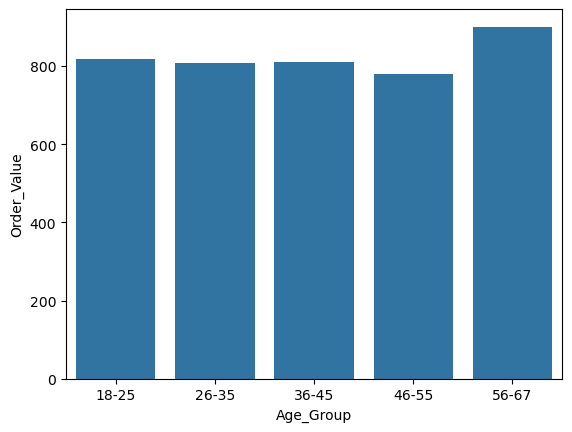

In [99]:
 sns.barplot(emp)

<Axes: xlabel='Age_Group', ylabel='Order_Value'>

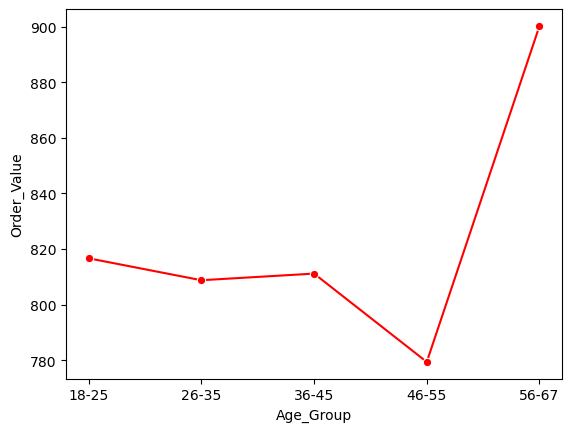

In [107]:
sns.lineplot(emp,marker='o',c='red')

yes we shoud create the vip category  for the age ==(56-67) its higher spend 